### Simulating a stochastic differential equation

https://ipython-books.github.io/134-simulating-a-stochastic-differential-equation/

This is one of the 100+ free recipes of the IPython Cookbook, Second Edition, by Cyrille Rossant, a guide to numerical computing and data science in the Jupyter Notebook. The ebook and printed book are available for purchase at Packt Publishing.

▶  Text on GitHub with a CC-BY-NC-ND license
▶  Code on GitHub with a MIT license

▶  Go to Chapter 13 : Stochastic Dynamical Systems
▶  Get the Jupyter notebook

Stochastic differential equations (SDEs) model dynamical systems that are subject to noise. They are widely used in physics, biology, finance, and other disciplines.

In this recipe, we simulate an Ornstein-Uhlenbeck process, which is a solution of the Langevin equation. This model describes the stochastic evolution of a particle in a fluid under the influence of friction. The particle's movement is due to collisions with the molecules of the fluid (diffusion). The difference with the Brownian motion is the presence of friction.

The Ornstein-Uhlenbeck process is stationary, Gaussian, and Markov, which makes it a good candidate to represent stationary random noise.

We will simulate this process with a numerical method called the Euler-Maruyama method. It is a simple generalization to SDEs of the Euler method for ODEs.

## How to do it...

#### 1.  Let's import NumPy and matplotlib:

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#### 2.  We define a few parameters for our model:

In [5]:
sigma = 1.  # standard deviation
mu = 10.    # mean.
tau = .05   # time constant

#### 3.  Let's define a few simulation parameters:

In [10]:
dt = .001  # time step
T = 1.  # total time
n = int(T / dt)  # number of time steps
t = np.linspace(0., T, n)  # vector of times
len(t)

1000

#### 4.  We also define renormalised variables (to avoid recomputing these constants at every time step):

In [11]:
sigma_bis = sigma * np.sqrt(2. / tau)
sqrtdt = np.sqrt(dt)

#### 5.  We create a vector that will contain all successive values of our process during the simulation:

In [14]:
x = np.zeros(n)
len(x)

1000

#### 6.  Now, let's simulate the process with the Euler-Maruyama method. It is really like the standard Euler method for ODEs, but with an extra stochastic term (which is just a scaled normal random variable). We will give the equation of the process along with the details of this method in the How it works... section:

In [18]:
for i in range(n - 1):
    x[i + 1] = x[i] + dt * (-(x[i] - mu) / tau) + \
        sigma_bis * sqrtdt * np.random.randn()

x[:5] # show first five elements of the resulting numpy array

array([0.        , 0.33755295, 0.2341903 , 0.72690784, 0.67771422])

#### 7. Let's display the evolution of the process:

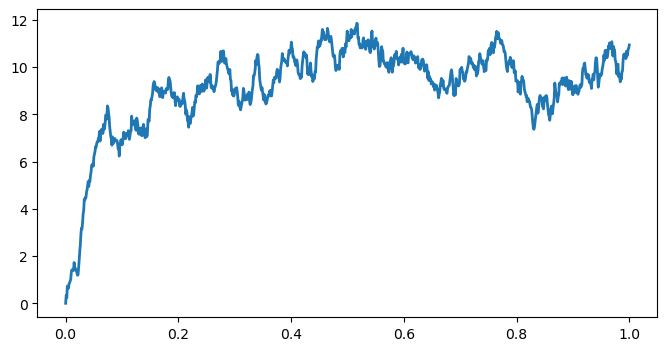

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(t, x, lw=2)

#### 8.  Now, we are going to take a look at the time evolution of the distribution of the process. To do this, we will simulate many independent realisations of the same process in a vectorised way. We define a vector X that will contain all realisations of the process at a given time (that is, we do not keep all realisations at all times in memory). This vector will be overwritten at every time step. We will show the estimated distribution (histograms) at several points in time:

In [20]:
ntrials = 10000
X = np.zeros(ntrials)

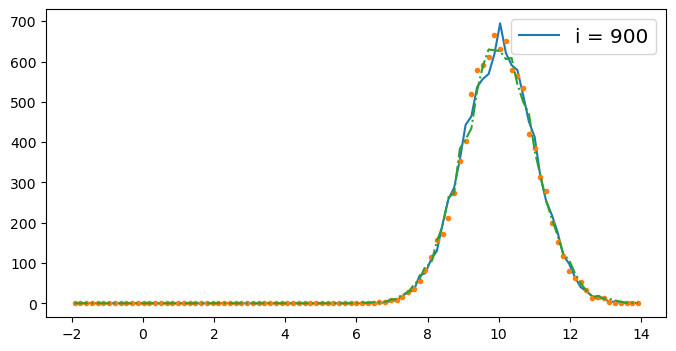

In [33]:
# we create bins for the histograms.
bins = np.linspace(-2., 14., 100)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

for i in range(n):
    # We update the process independently for
    # all trials
    X += dt * (-(X - mu) / tau) + \
        sigma_bis * sqrtdt * np.random.randn(ntrials)
    # We display the histogram for a few points in
    # time
    if i in (5, 50, 900):
        hist, _ = np.histogram(X, bins=bins)
        ax.plot((bins[1:] + bins[:-1]) / 2, hist,
                {5: '-', 50: '.', 900: '-.', }[i],
                label=f"t={i * dt:.2f}")
        ax.legend(["i = " + str(i)], fontsize="x-large")

plt.show()
# plt.legend(["This is my legend"], fontsize="x-large")

#### How it works...

#### The Langevin equation that we use in this recipe is the following stochastic differential equation:

dx=−(x−μ)τdt+σ2τ−−√dW
Here, x(t)
 is our stochastic process, dx
 is the infinitesimal increment, μ
 is the mean, σ
 is the standard deviation, and τ
 is the time constant. Also, W
 is a Brownian motion (or the Wiener process) that underlies our SDE.

The first term on the right-hand side is the deterministic term (in dt
), while the second term is the stochastic term. Without that last term, the equation would be a regular deterministic ODE.

The infinitesimal step of a Brownian motion is a Gaussian random variable. Specifically, the derivative (in a certain sense) of a Brownian motion is a white noise, a sequence of independent Gaussian random variables.

The Euler-Maruyama method involves discretizing time and adding infinitesimal steps to the process at every time step. This method involves a deterministic term (like in the standard Euler method for ODEs) and a stochastic term (random Gaussian variable). Specifically, for an equation:

dx=a(t,x)dt+b(t,x)dW
The numerical scheme is (with t=n∗dt
):

xn+1=xn+dx=xn+a(t,xn)dt+b(t,xn)dt−−√ξ,ξ∼N(0,1)
Here, ξ
 is a random Gaussian variable with variance 1 (independent at each time step). The normalization factor dt−−√
 comes from the fact that the infinitesimal step for a Brownian motion has the standard deviation dt−−√
 .

#### There's more...

#### The mathematics of SDEs comprises the theory of stochastic calculus, Itō calculus, martingales, and other topics. Although these theories are quite involved, simulating stochastic processes numerically can be relatively straightforward, as we have seen in this recipe.

The error of the Euler-Maruyama method is of order dt−−√
. The Milstein method is a more precise numerical scheme, of order dt
.

#### Here are a few references on these topics:

Stochastic differential equations on Wikipedia, available at https://en.wikipedia.org/wiki/Stochastic_differential_equation
White noise, described at https://en.wikipedia.org/wiki/White_noise
The Langevin equation on Wikipedia, available at https://en.wikipedia.org/wiki/Langevin_equation
The Ornstein-Uhlenbeck process described at https://en.wikipedia.org/wiki/Ornstein%E2%80%93Uhlenbeck_process
Itō calculus, described at https://en.wikipedia.org/wiki/It%C5%8D_calculus
The Euler-Maruyama method, explained at https://en.wikipedia.org/wiki/Euler%E2%80%93Maruyama_method
The Milstein method on Wikipedia, available at https://en.wikipedia.org/wiki/Milstein_method